<a href="https://colab.research.google.com/github/omzeybek/Yeditepe_Data_Science_DATS501/blob/main/Week8_Supervised_Learning_Random_Forrest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#DATS 501 Week 9 Supervised Learning / Coding Session
**Supervised Learning** - *RECAP*

Supervised learning is the most common subfield of Machine Learning. At its core, it is about teaching by example.

Random Forest is an ensemble learning method that combines many decision trees to produce more accurate and robust predictions than any single tree. It was introduced by Leo Breiman in 2001 and remains one of the most widely used algorithms for both classification and regression.


Predicting house prices on the California Housing dataset
using a Random Forest regressor.

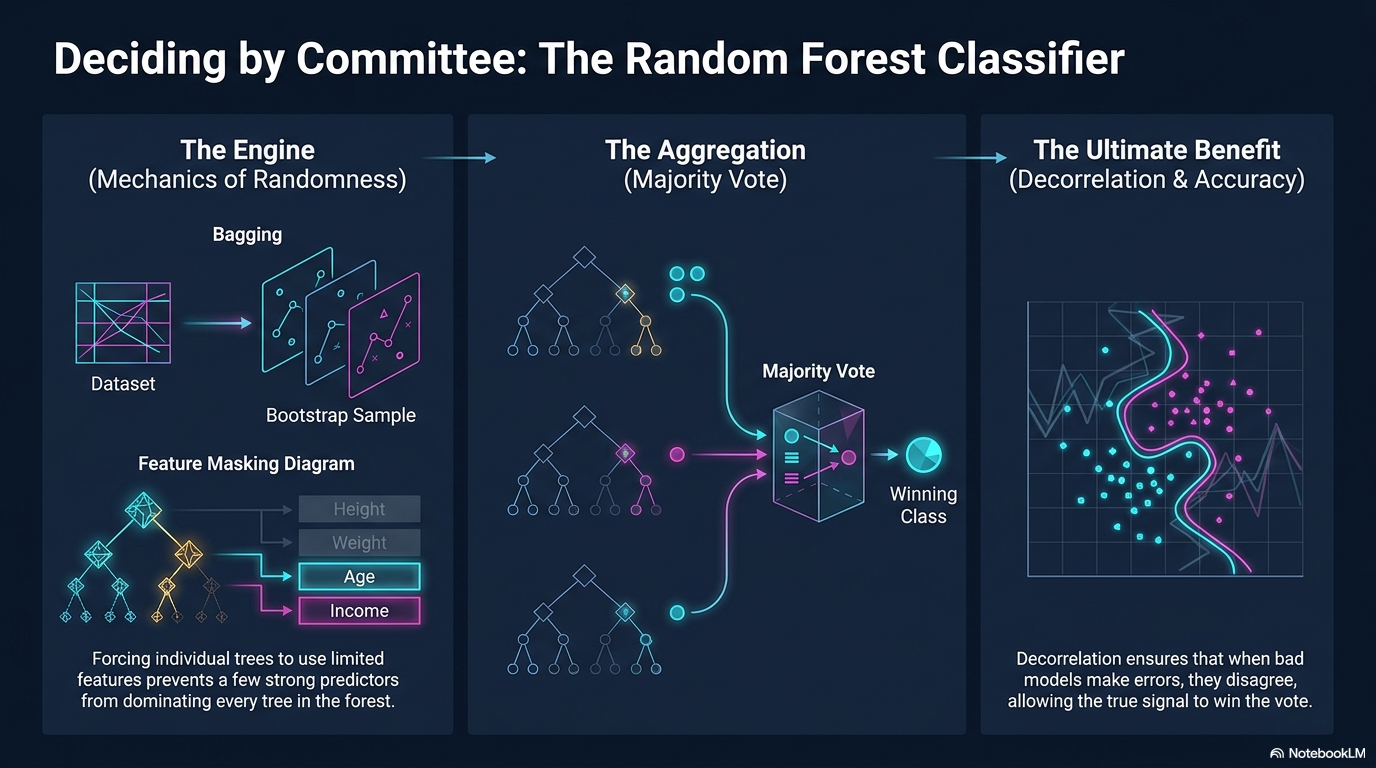

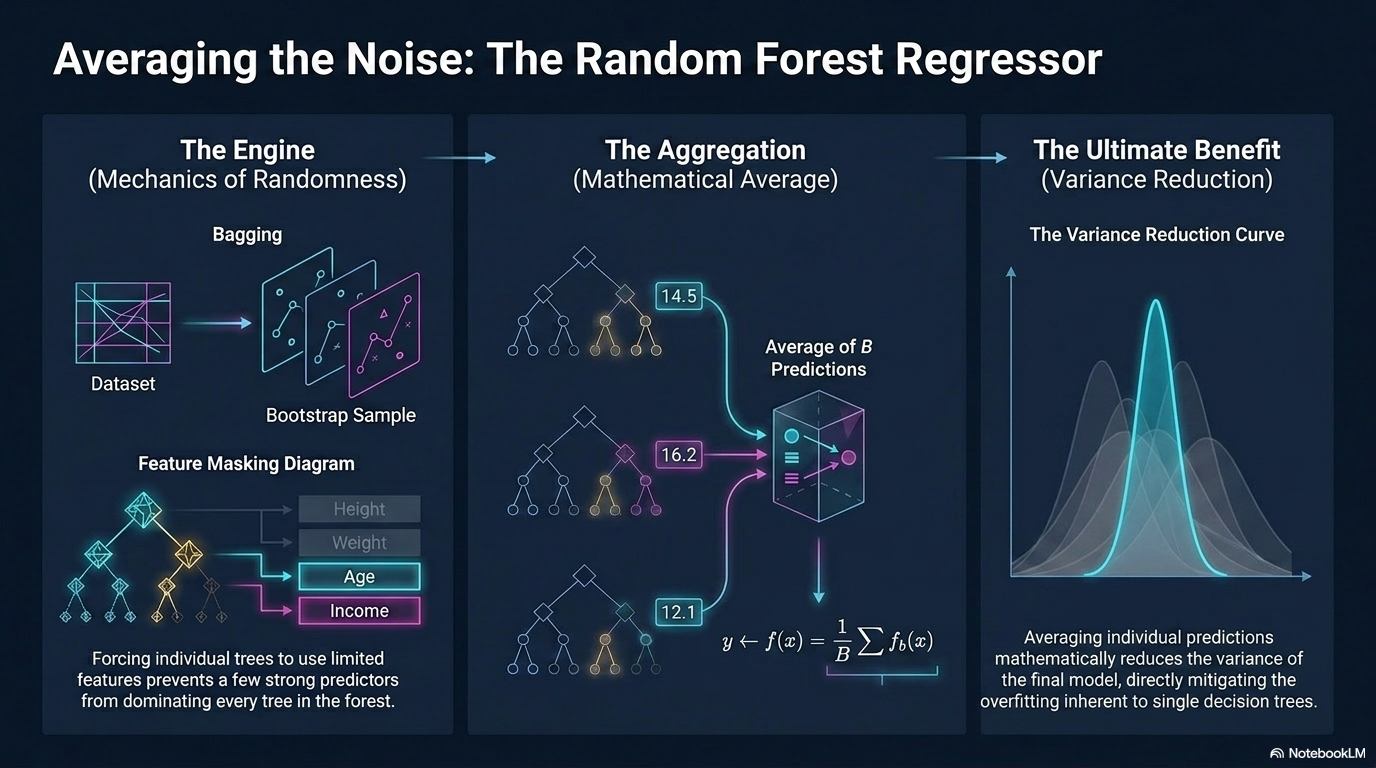

***1.Regression***


Regression algorithms predict a continuous numerical target from input features. The field is much richer than just "linear regression" — there are dozens of algorithms with very different assumptions, strengths, and use cases. Let me organize them into families:


##Random Forrest Regressor Workflow


Topic   : Predicting house prices on the California Housing dataset

Dataset : California Housing Data Set

Models  : Random Forest

A Random Forest Regressor is an ensemble learning method that builds many decision trees during training and outputs the average of their predictions. It is one of the most widely used algorithms for tabular regression problems because it requires little tuning, handles non-linear relationships well, and is robust to outliers.

## Import Packages

At the first step, we will import the packages used for Random Forrest Estimation.

In [ ]:
import numpy as np  #for numeric operations
import pandas as pd #Tidy data for ML operations
import matplotlib.pyplot as plt #Basic plotting
from sklearn.datasets import fetch_california_housing #importing my tutorial data from sklearn
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score #Model evaluation
from sklearn.ensemble import RandomForestRegressor # Estimator
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score # Goodness of fit metrics

##Load Data

In [ ]:
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="MedHouseVal")  # in units of $100,000

In [ ]:
print(data.DESCR)

In [ ]:
print("Dataset shape:", X.shape)
print("\nFeatures:")
print(X.head())
print("\nTarget statistics (MedHouseVAl):")
print(y.describe())

## Data Processing

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Adjusting Hyperparameters

A **hyperparameter** is a property of a machine learning algorithm that influences how the algorithm operates. The defining characteristic of a hyperparameter is that it is not learned by the algorithm itself from the training data.



*   These values must be set by the data analyst before running the algorithm
*   This is in contrast to regular parameters, which are variables that the learning algorithm directly modifies and learns from the data in order to optimize the mode.
*   Regarding Random Forests, the number of trees and the size of the random feature subsets are both hyperparameters.
*   Because the algorithm cannot optimize these values on its own, analysts must "tune" hyperparameters experimentally to find the most effective combination for the problem at hand.



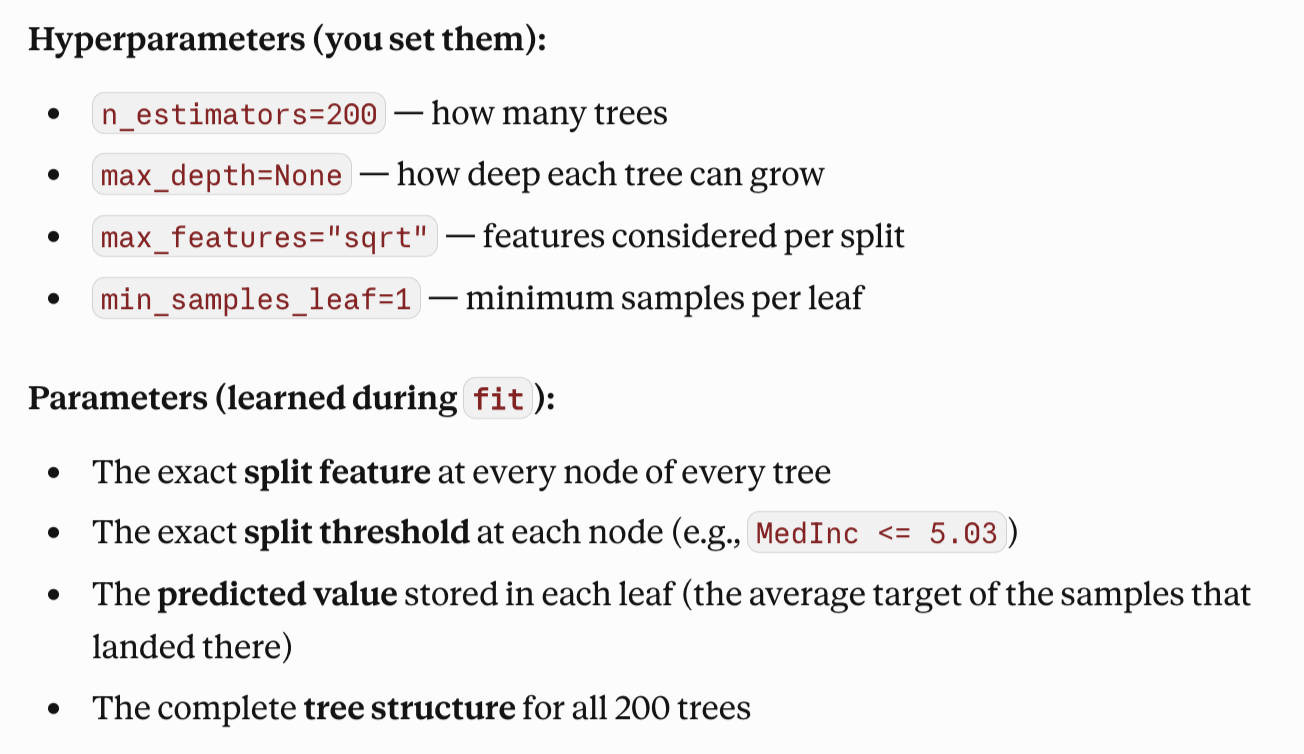

Create baseline RandomForestRegressor with appropriate hyper-parameter setting:

In [ ]:
rf = RandomForestRegressor(
    n_estimators=200,        # number of trees
    max_depth=None,          # grow until pure
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",     # sqrt(n_features) at each split
    n_jobs=-1,               # use all CPU cores
    random_state=42,
)

Here we specified a baseline model. Now it's time to fit this model on our data

In [ ]:

rf.fit(X_train, y_train)

## Model Evaluation

**Step 1** is to score our model with the data points assinged on test data set.

In [ ]:
print(y_test.shape)
y_pred = rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Test performance ---")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R^2  : {r2:.4f}")

With high R-square at 0.81 level and **low error rate** at MAE level (How do you know MAE is acceptable???) our model seems as a MVP. But there are other potential prediction biases arising from the factors that simple evaluation metrics are not able to catch.  

Such as overfitting

In [ ]:
# 5-fold cross-validation (R^2)
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring="r2", n_jobs=-1)
print(f"CV R^2 mean: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


**Step 2** CV R-square is almost same with test set performance than existing model might be reliable. However it's a good idea to check if we are able to reach a better hyper-parameter setting.

## Hyper-Parameter Tuning



Grid search for hyperparameter tuning is a systematic way to find the best hyperparameters for a machine learning model.

* You define a set (grid) of possible hyperparameter values.
* The algorithm tries every possible combination.
* Each combination is evaluated using cross‑validation.
* The one with the best performance score is selected.

First step we should go is to specify boundaries for our search horizon

In [ ]:
param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "max_features": ["sqrt", 0.5],
}


Then every values included in our grid search net will be tested and evaluated. For this example, GridSearchCV will try to located minimum RMSE. Finally the best model setting to be saved under **grid** object.


In [ ]:
grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1,
)

Let's fit our training sets on newly created model.

In [ ]:
grid.fit(X_train, y_train)


Now report evaluation metrics for best grid model.

In [ ]:

print("\nBest parameters:", grid.best_params_)
print(f"Best CV RMSE   : {-grid.best_score_:.4f}")

best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)
print(f"Tuned test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_best)):.4f}")
print(f"Tuned test R^2 : {r2_score(y_test, y_pred_best):.4f}")




print("\nPlots saved: feature_importances.png, pred_vs_actual.png")

## Bonus

Fature İmpoortance

In [ ]:
# 6) Feature importances
# ---------------------------------------------------------------
importances = pd.Series(best_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind="barh")
plt.title("Random Forest - Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()



# 7) Predicted vs Actual plot
# ---------------------------------------------------------------
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_best, alpha=0.3, s=10)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, "r--", linewidth=2, label="Perfect prediction")
plt.xlabel("Actual value")
plt.ylabel("Predicted value")
plt.title("Random Forest - Predicted vs Actual")
plt.legend()
plt.tight_layout()
